In [539]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

In [540]:
df_canais = pd.read_csv('../../dados/clean/canais.csv', sep=';')
df_clientes = pd.read_csv('../../dados/clean/clientes.csv', sep=';')
df_funcionarios = pd.read_csv('../../dados/clean/funcionarios.csv', sep=';')
df_reservas = pd.read_csv('../../dados/clean/reservas.csv', sep=';')
df_t_quartos = pd.read_csv('../../dados/clean/tipos_quarto.csv', sep=';')
df_unidades = pd.read_csv('../../dados/clean/unidades.csv', sep=';')

In [541]:
df_reservas

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão De Crédito
1,2,5,1,261,4,2023-09-28,2023-10-01,3,2,1.0,Confirmada,Pix
2,3,10,4,49,4,2023-08-01,2023-08-06,5,1,9.0,Confirmada,Cartão De Crédito
3,4,6,2,23,2,2023-02-18,2023-02-21,3,1,9.0,Cancelada,Pix
4,5,7,1,42,1,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
...,...,...,...,...,...,...,...,...,...,...,...,...
4644,3198,7,5,268,1,2026-08-05,2026-08-07,2,2,9.0,Confirmada,Cartão De Débito
4645,3490,9,3,48,1,2026-05-24,2026-05-26,2,3,8.0,Confirmada,Transferência
4646,4579,13,6,306,4,2026-04-16,2026-04-18,2,4,0.0,Confirmada,Dinheiro
4647,3882,11,1,100,4,2025-01-03,2025-01-06,3,1,8.0,Confirmada,Cartão De Débito


## Correção para datetime já que o dtype de datetime não é puxado

In [542]:
df_funcionarios['data_admissao'] = pd.to_datetime(
    df_funcionarios['data_admissao'],
    yearfirst=True
)
df_reservas['data_checkin'] = pd.to_datetime(
    df_reservas['data_checkin'],
    yearfirst=True
)
df_reservas['data_checkout'] = pd.to_datetime(
    df_reservas['data_checkout'],
    yearfirst=True
)

## Pergunta 1

#### Preparando para responder as perguntas:

In [543]:
df_unidade_reserva = pd.merge(df_reservas, df_unidades, on='id_unidade', how='inner')
df_uni_res_quart = pd.merge(df_unidade_reserva, df_t_quartos, on='id_tipo_quarto', how='inner')
df_no_cancel = df_uni_res_quart[df_uni_res_quart['status_reserva'] != 'Cancelada']

In [544]:
df_no_cancel['preco_total'] = df_no_cancel['qtd_diarias'] * df_no_cancel['valor_diaria_base']

#### Comportamento das diárias:

#### O quarto mais procurado para reservas é o Deluxe de 580 reais

In [545]:
array_diaria = np.array(df_no_cancel['valor_diaria_base'])
media_diaria = np.mean(array_diaria)
mediana_diaria = np.median(array_diaria)
q1_diaria = np.percentile(array_diaria, 25)
q3_diaria = np.percentile(array_diaria, 75)
distancia = (media_diaria - mediana_diaria) / mediana_diaria

print(f'Media: {round(media_diaria, 2)} \nMediana: {mediana_diaria} \nDistancia: {distancia:.2%}')
print(f'Q1: {q1_diaria} Q3: {q3_diaria}')

Media: 645.95 
Mediana: 580.0 
Distancia: 11.37%
Q1: 420.0 Q3: 950.0


In [546]:
iqr_med = q3_diaria - q1_diaria
l_sup_med = q3_diaria + (iqr_med*1.5)
l_inf_med = q1_diaria - (iqr_med*1.5)
print(l_sup_med, l_inf_med)

1745.0 -375.0


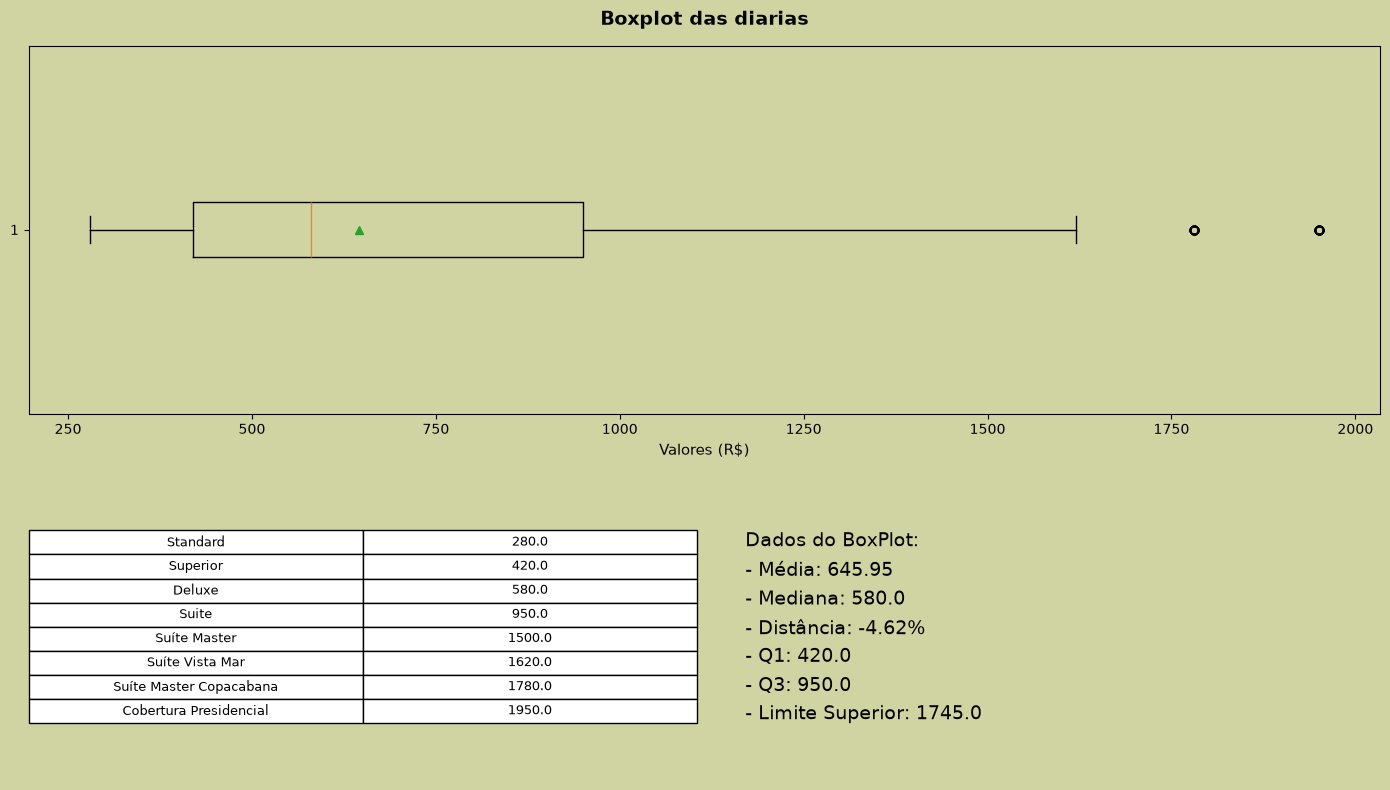

In [640]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"

# Criando a figura com GridSpec (2 linhas, 2 colunas)
fig = plt.figure(figsize=(14, 8), facecolor=cor_fundo_ppt)
gs = GridSpec(2, 2, figure=fig, width_ratios=[1, 1], height_ratios=[1.2, 1])

# 1. Boxplot ocupando toda a linha superior (linha 0, colunas 0 e 1)
ax_grafico = fig.add_subplot(gs[0, :])
ax_grafico.set_facecolor(cor_fundo_ppt)

ax_grafico.boxplot(array_diaria, orientation="horizontal", showmeans=True)
ax_grafico.set_title(
    "Boxplot das diarias", fontsize=14, color=cor_texto, pad=15, fontweight="bold"
)
ax_grafico.set_xlabel("Valores (R$)", fontsize=11, color=cor_texto)

# 2. Informações de Texto na coordenada inferior esquerda [1, 0]
ax_texto = fig.add_subplot(gs[1, 1])
ax_texto.set_facecolor(cor_fundo_ppt)
ax_texto.axis("off")

texto_explicativo = (
    "Dados do BoxPlot:\n"
    f"- Média: {media_diaria:.2f}\n"
    f"- Mediana: {mediana_diaria}\n"
    f"- Distância: {distancia:.2%}\n"
    f"- Q1: {q1_diaria}\n"
    f"- Q3: {q3_diaria}\n"
    f"- Limite Superior: {l_sup_med}"
)

ax_texto.text(
    0.05,
    0.5,
    texto_explicativo,
    fontsize=14,
    color=cor_texto,
    va="center",
    ha="left",
    family="sans-serif",
    linespacing=1.5,
)

ax_tabela = fig.add_subplot(gs[1, 0])
ax_tabela.set_facecolor("none")
ax_tabela.axis("off")

df_tq_plt = df_t_quartos[['descricao', 'valor_diaria_base']]
tabela = ax_tabela.table(
    cellText=df_tq_plt.values,
    loc="center",
    cellLoc="center",
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)  # Fonte um pouco menor para ajustar bem no canto inferior
tabela.scale(1, 1.2)

plt.tight_layout()
plt.show()

In [548]:
outlier_sup = df_no_cancel.loc[df_no_cancel['valor_diaria_base'] > l_sup_med]
outlier_inf = df_no_cancel.loc[df_no_cancel['valor_diaria_base'] < l_inf_med]
outlier_sup['descricao'].value_counts()

descricao
Suíte Master Copacabana    46
Cobertura Presidencial     44
Name: count, dtype: int64

In [549]:
df_unidades[['id_unidade', 'nome_unidade', 'categoria_hotel', 'num_quartos_total', 'regiao']]

,id_unidade,nome_unidade,categoria_hotel,num_quartos_total,regiao
0,1,NaraHoteis Ipanema,5 Estrelas,80,Capital
1,2,NaraHoteis Barra da Tijuca,4 Estrelas,120,Capital
2,3,NaraHoteis Centro,3 Estrelas,60,Capital
3,4,NaraHoteis Santa Teresa,4 Estrelas,45,Capital
4,5,NaraHoteis Nova Iguaçu Centro,3 Estrelas,50,Baixada Fluminense
5,6,NaraHoteis Nova Iguaçu Park,3 Estrelas,55,Baixada Fluminense
6,7,NaraHoteis Petrópolis,5 Estrelas,70,Serra
7,8,NaraHoteis Teresópolis,4 Estrelas,60,Serra
8,9,NaraHoteis Friburgo,4 Estrelas,55,Serra
9,10,NaraHoteis Paraty,5 Estrelas,75,Costa Verde


#### Faturamento por unidade:

In [550]:
df_faturamento = df_no_cancel.groupby(['id_unidade', 'nome_unidade', 'regiao'])['preco_total'].sum().reset_index().sort_values(by='preco_total', ascending=False)

In [551]:
df_faturamento

,id_unidade,nome_unidade,regiao,preco_total
11,12,NaraHoteis Mangaratiba,Costa Verde,777300.0
9,10,NaraHoteis Paraty,Costa Verde,773440.0
8,9,NaraHoteis Friburgo,Serra,744480.0
5,6,NaraHoteis Nova Iguaçu Park,Baixada Fluminense,735490.0
3,4,NaraHoteis Santa Teresa,Capital,734400.0
7,8,NaraHoteis Teresópolis,Serra,723170.0
6,7,NaraHoteis Petrópolis,Serra,700170.0
1,2,NaraHoteis Barra da Tijuca,Capital,697680.0
10,11,NaraHoteis Angra dos Reis,Costa Verde,690230.0
0,1,NaraHoteis Ipanema,Capital,688410.0


##### Quartos mais reservados nas 5 unidades com maior faturamento:

In [552]:
df_comportamento_unidade = df_no_cancel.groupby(['id_unidade', 'nome_unidade', 'descricao'])['descricao'].value_counts().reset_index()
df_unidades_5 = df_comportamento_unidade.loc[df_comportamento_unidade['id_unidade'].isin([12, 10, 9, 6, 4])].sort_values(by=['id_unidade', 'count'], ascending=[True, False])
df_top2_por_unidade = df_unidades_5.groupby('id_unidade').head(2)
df_top2_por_unidade_graf = df_top2_por_unidade[['nome_unidade', 'descricao']]
df_top2_por_unidade_graf

,nome_unidade,descricao
17,NaraHoteis Santa Teresa,Superior
14,NaraHoteis Santa Teresa,Deluxe
23,NaraHoteis Nova Iguaçu Park,Deluxe
26,NaraHoteis Nova Iguaçu Park,Superior
38,NaraHoteis Friburgo,Deluxe
41,NaraHoteis Friburgo,Superior
43,NaraHoteis Paraty,Deluxe
46,NaraHoteis Paraty,Superior
53,NaraHoteis Mangaratiba,Deluxe
54,NaraHoteis Mangaratiba,Standard


##### Medida central das avaliações da cada hotel e número de quartos, para entender o que está influênciando os dados de faturamento:

In [553]:
df_avaliac_unidade = df_no_cancel.groupby(['id_unidade', 'nome_unidade'])['avaliacao_hospede'].median().reset_index()
df_avaliac_unidade

,id_unidade,nome_unidade,avaliacao_hospede
0,1,NaraHoteis Ipanema,8.0
1,2,NaraHoteis Barra da Tijuca,7.0
2,3,NaraHoteis Centro,2.0
3,4,NaraHoteis Santa Teresa,8.0
4,5,NaraHoteis Nova Iguaçu Centro,2.0
5,6,NaraHoteis Nova Iguaçu Park,7.0
6,7,NaraHoteis Petrópolis,7.0
7,8,NaraHoteis Teresópolis,8.0
8,9,NaraHoteis Friburgo,7.0
9,10,NaraHoteis Paraty,8.0


In [554]:
df_client_uni_reser = pd.merge(df_no_cancel, df_clientes, on='id_cliente', how='inner')
df_nicho_cliente = df_client_uni_reser.groupby(['id_unidade', 'nome_unidade', 'estado_origem'])['estado_origem'].value_counts().reset_index()

In [555]:
df_nicho_cliente = df_nicho_cliente.sort_values(
    by=['id_unidade', 'count'], 
    ascending=[True, False]
)
df_nicho_unidade = df_nicho_cliente.groupby(['id_unidade', 'nome_unidade']).head(1).reset_index(drop=True)
df_nicho_unidade_graf = df_nicho_unidade[['nome_unidade', 'estado_origem']]
df_nicho_unidade_graf

,nome_unidade,estado_origem
0,NaraHoteis Ipanema,PE
1,NaraHoteis Barra da Tijuca,CE
2,NaraHoteis Centro,PE
3,NaraHoteis Santa Teresa,MG
4,NaraHoteis Nova Iguaçu Centro,CE
5,NaraHoteis Nova Iguaçu Park,PE
6,NaraHoteis Petrópolis,CE
7,NaraHoteis Teresópolis,CE
8,NaraHoteis Friburgo,PE
9,NaraHoteis Paraty,CE


correlação fazer, para entender porque o que define um faturamento alto 

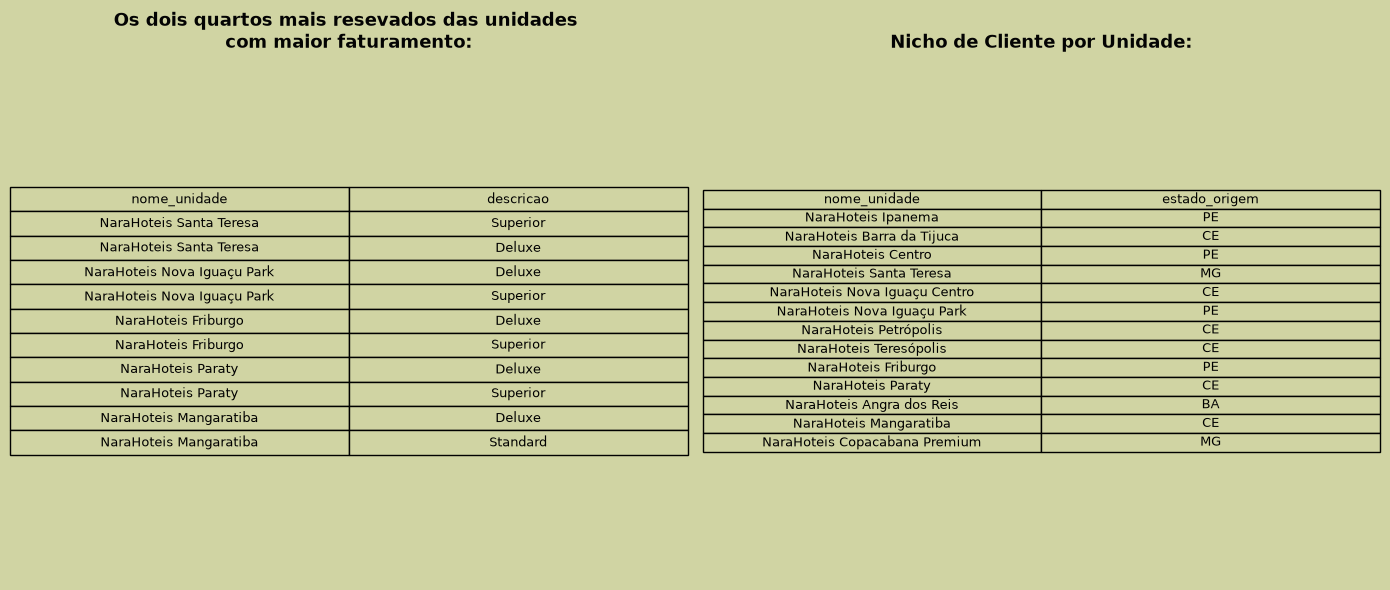

In [611]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor=cor_fundo_ppt)

# --- Subplot 1: DataFrame de Top 2 Quartos ---
ax1.set_facecolor(cor_fundo_ppt)
ax1.axis('off')
tabela1 = ax1.table(
    cellText=df_top2_por_unidade_graf.values,
    colLabels=df_top2_por_unidade_graf.columns,
    loc='center',
    cellLoc='center'
)
tabela1.auto_set_font_size(False)
tabela1.set_fontsize(9)
tabela1.scale(1, 1.3)

# Removendo o fundo branco das células da tabela 1
for key, cell in tabela1.get_celld().items():
    cell.set_facecolor(cor_fundo_ppt)

ax1.set_title("Os dois quartos mais resevados das unidades \ncom maior faturamento:", fontsize=13, color=cor_texto, fontweight="bold", pad=10)

# --- Subplot 2: DataFrame de Nicho de Cliente ---
ax2.set_facecolor(cor_fundo_ppt)
ax2.axis('off')
tabela2 = ax2.table(
    cellText=df_nicho_unidade_graf.values,
    colLabels=df_nicho_unidade_graf.columns,
    loc='center',
    cellLoc='center'
)
tabela2.auto_set_font_size(False)
tabela2.set_fontsize(9)
tabela2.scale(1, 1)

# Removendo o fundo branco das células da tabela 2
for key, cell in tabela2.get_celld().items():
    cell.set_facecolor(cor_fundo_ppt)

ax2.set_title("Nicho de Cliente por Unidade:", fontsize=13, color=cor_texto, fontweight="bold", pad=10)

plt.tight_layout()
plt.show()

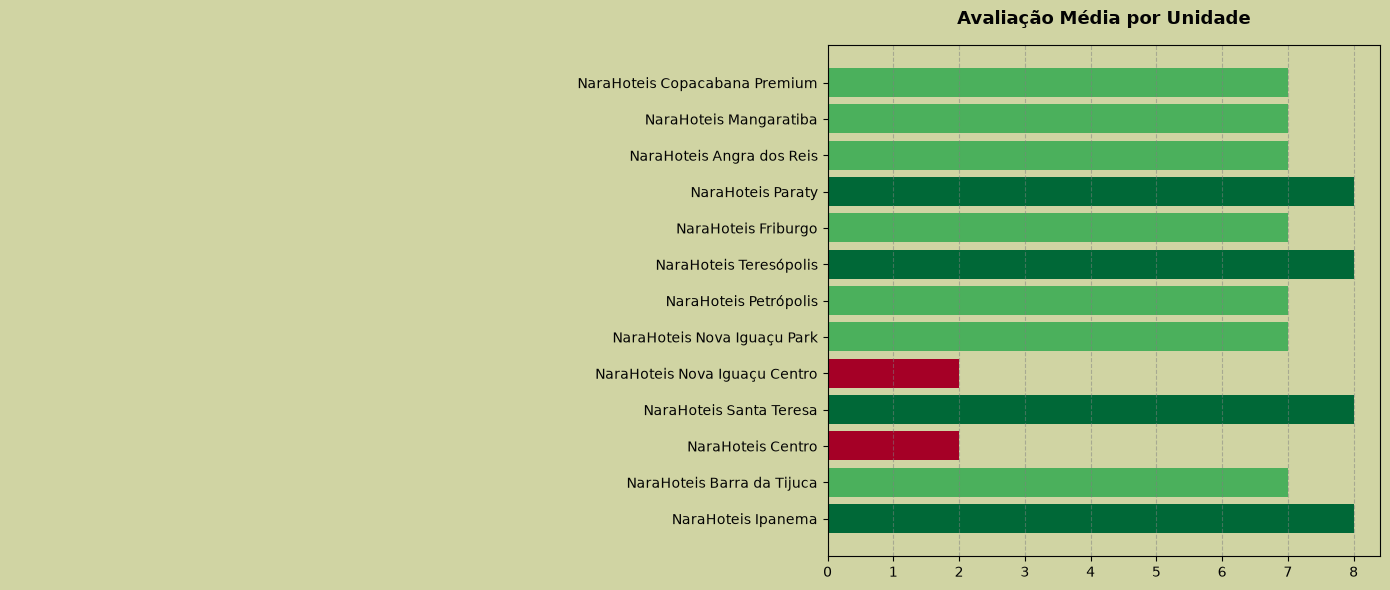

In [557]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"
minhas_cores = ['#2C3E50', '#34495E', '#4A90E2', '#5DADE2', '#3498DB', '#2980B9', '#1B4F72']

# Criando a figura com 1 linha e 2 colunas lado a lado
fig, (ax_tabela, ax_grafico) = plt.subplots(1, 2, figsize=(14, 6), facecolor=cor_fundo_ppt)

# Definindo a cor de fundo dos eixos
ax_tabela.set_facecolor(cor_fundo_ppt)
ax_grafico.set_facecolor(cor_fundo_ppt)

# --- Coluna 1: Totalmente Vazia / Limpa ---
ax_tabela.axis("off")
# Removendo título e qualquer elemento visual da primeira coluna para ficar totalmente em branco

# --- Coluna 2: Gráfico de Avaliação Média (Cores de verde a vermelho) ---
norm = plt.Normalize(df_avaliac_unidade['avaliacao_hospede'].min(), df_avaliac_unidade['avaliacao_hospede'].max())
cmap = plt.get_cmap('RdYlGn')
cores_barras = [cmap(norm(val)) for val in df_avaliac_unidade['avaliacao_hospede']]

bars = ax_grafico.barh(
    df_avaliac_unidade['nome_unidade'], 
    df_avaliac_unidade['avaliacao_hospede'], 
    color=cores_barras
)
ax_grafico.set_title("Avaliação Média por Unidade", fontsize=13, color=cor_texto, fontweight="bold", pad=15)
ax_grafico.tick_params(colors=cor_texto)
ax_grafico.grid(axis='x', linestyle='--', alpha=0.5, color='gray')

# Ajustando as bordas do gráfico para o tema
for spine in ax_grafico.spines.values():
    spine.set_color(cor_texto)

# Ajuste final de layout
plt.tight_layout()
plt.show()

## Pergunta 2

In [558]:
no_show = df_no_cancel.loc[df_no_cancel['status_reserva'] == 'No-Show']
no_show_total = no_show.groupby(['id_unidade'])['id_reserva'].count().reset_index(name='No-Show')
total_reserv = df_no_cancel.groupby(['id_unidade', 'nome_unidade'])['id_reserva'].count().reset_index(name='Total Reservas')
no_show_total = pd.merge(total_reserv, no_show_total, on='id_unidade', how='inner')
no_show_total['Taxa No-Show'] = round((no_show_total['No-Show'] / no_show_total['Total Reservas']) * 100, 2)
no_show_total

,id_unidade,nome_unidade,Total Reservas,No-Show,Taxa No-Show
0,1,NaraHoteis Ipanema,312,19,6.09
1,2,NaraHoteis Barra da Tijuca,302,19,6.29
2,3,NaraHoteis Centro,436,26,5.96
3,4,NaraHoteis Santa Teresa,340,20,5.88
4,5,NaraHoteis Nova Iguaçu Centro,376,24,6.38
5,6,NaraHoteis Nova Iguaçu Park,292,17,5.82
6,7,NaraHoteis Petrópolis,288,17,5.90
7,8,NaraHoteis Teresópolis,298,16,5.37
8,9,NaraHoteis Friburgo,309,22,7.12
9,10,NaraHoteis Paraty,309,14,4.53


## Pergunta 3

O ticket medio com certeza geraria um outlier já que os quartos de certas unidades são mais caros por natureza, então o faturamento é a melhor forma de mostrar a performace da receita das unidade

In [559]:
array_faturamento = np.array(df_faturamento['preco_total'])

In [560]:
media_fat = np.mean(array_faturamento)
mediana_fat = np.median(array_faturamento)
q1_fat = np.percentile(array_faturamento, 25)
q3_fat = np.percentile(array_faturamento, 75)
distancia = (media_fat - mediana_fat) / mediana_fat

print(f'Media: {round(media_fat, 2)} \nMediana: {mediana_fat} \nDistancia: {round(distancia, 2)}')
print(f'Q1: {q1_fat} Q3: {q3_fat}')

Media: 667806.92 
Mediana: 700170.0 
Distancia: -0.05
Q1: 688410.0 Q3: 735490.0


In [561]:
iqr_fat = q3_fat - q1_fat
l_sup_fat = q3_fat + (iqr_fat*1.5)
l_inf_fat = q1_fat - (iqr_fat*1.5)
print(l_sup_fat, l_inf_fat)

806110.0 617790.0


In [634]:
outliers_inf_fat = df_faturamento[['nome_unidade', 'regiao', 'preco_total']].loc[df_faturamento['preco_total'] < l_inf_fat]
outliers_inf_fat

,nome_unidade,regiao,preco_total
12,NaraHoteis Copacabana Premium,Capital,604880.0
2,NaraHoteis Centro,Capital,440040.0
4,NaraHoteis Nova Iguaçu Centro,Baixada Fluminense,371800.0


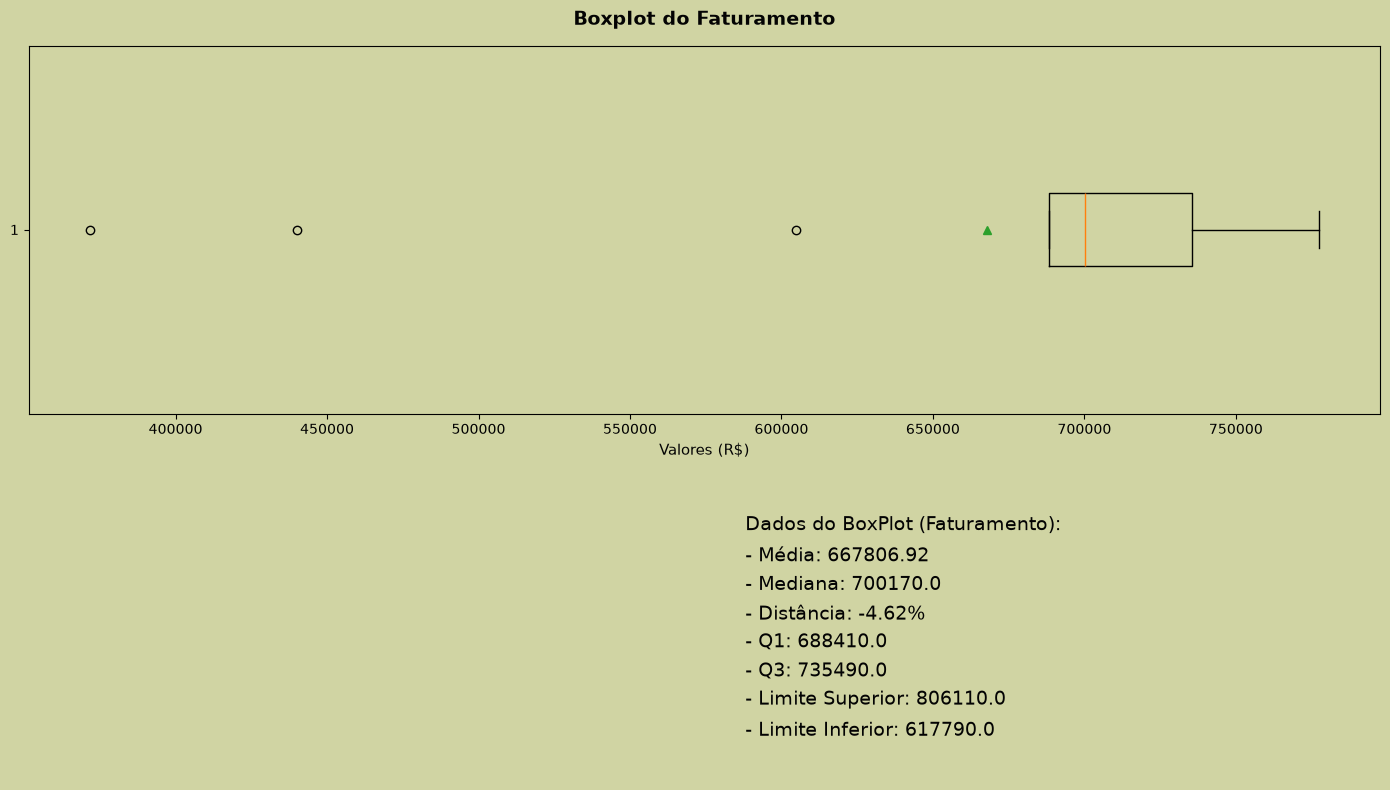

In [655]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"

# Criando a figura com GridSpec (2 linhas, 2 colunas)
fig = plt.figure(figsize=(14, 8), facecolor=cor_fundo_ppt)
gs = GridSpec(2, 2, figure=fig, width_ratios=[1, 1], height_ratios=[1.2, 1])

# 1. Boxplot ocupando toda a linha superior com os dados de faturamento
ax_grafico = fig.add_subplot(gs[0, :])
ax_grafico.set_facecolor(cor_fundo_ppt)

ax_grafico.boxplot(array_faturamento, orientation="horizontal", showmeans=True, widths=0.2)
ax_grafico.set_title(
    "Boxplot do Faturamento", fontsize=14, color=cor_texto, pad=15, fontweight="bold"
)
ax_grafico.set_xlabel("Valores (R$)", fontsize=11, color=cor_texto)

# 2. Informações de Texto estatísticas na coordenada inferior direita [1, 1]
ax_texto = fig.add_subplot(gs[1, 1])
ax_texto.set_facecolor(cor_fundo_ppt)
ax_texto.axis("off")

texto_explicativo = (
    "Dados do BoxPlot (Faturamento):\n"
    f"- Média: {media_fat:.2f}\n"
    f"- Mediana: {mediana_fat}\n"
    f"- Distância: {distancia:.2%}\n"
    f"- Q1: {q1_fat}\n"
    f"- Q3: {q3_fat}\n"
    f"- Limite Superior: {l_sup_fat}\n"
    f"- Limite Inferior: {l_inf_fat}"
)

ax_texto.text(
    0.05,
    0.5,
    texto_explicativo,
    fontsize=14,
    color=cor_texto,
    va="center",
    ha="left",
    family="sans-serif",
    linespacing=1.5,
)

# 3. Espaço vazio na coordenada inferior esquerda [1, 0] (substituindo a tabela)
ax_vazio = fig.add_subplot(gs[1, 0])
ax_vazio.set_facecolor(cor_fundo_ppt)
ax_vazio.axis("off")

plt.tight_layout()
plt.show()

## Pergunta 4:

Primeira parte, recortando 2 periodos diferentes

Recorte total, desde o lançamento de cada unidade:

In [563]:
# Average Daily Rate, resumindo valor medio das diarias
df_adr = df_no_cancel.groupby(['id_unidade', 'nome_unidade', 'num_quartos_total'])['valor_diaria_base'].mean().reset_index(name='adr')

In [564]:
df_diarias_vendidas = df_no_cancel.groupby('id_unidade')['qtd_diarias'].sum().reset_index(name='diarias_vendidas')

df_dias_unidade = df_no_cancel.groupby('id_unidade').agg(
    min_checkin=('data_checkin', 'min'),
    max_checkout=('data_checkout', 'max')
).reset_index()
# .days para extrair apenas o número inteiro do Deltatime, subtração de data
# Resumindo esse valor é a quantidade de diarias disponiveis 
df_dias_unidade['dias_operacao'] = (df_dias_unidade['max_checkout'] - df_dias_unidade['min_checkin']).dt.days

df_revpar = pd.merge(df_adr, df_diarias_vendidas, on='id_unidade')

# Total de quartos disponíveis no período histórico
df_revpar['quartos_disponiveis_total'] = df_revpar['num_quartos_total'] * df_dias_unidade['dias_operacao']

# Taxa de Ocupação (% das diárias vendidas sobre a capacidade total do período), sem porcentagem para o calculo 
df_revpar['taxa_ocupacao'] = (df_revpar['diarias_vendidas'] / df_revpar['quartos_disponiveis_total']) 

In [565]:
df_revpar['media_revpar'] = df_revpar['adr'] * df_revpar['taxa_ocupacao']
df_revpar['faturamento_revpar'] = df_faturamento['preco_total'] / df_revpar['quartos_disponiveis_total']

In [566]:
df_revpar['avaliacao_media'] = df_avaliac_unidade['avaliacao_hospede']

In [567]:
# Formatações
df_revpar['taxa_ocupacao'] = round((df_revpar['diarias_vendidas'] / df_revpar['quartos_disponiveis_total']) * 100, 2)
df_revpar['adr'] = round(df_revpar['adr'], 2)
df_revpar['media_revpar'] = round(df_revpar['media_revpar'], 2)
df_revpar['faturamento_revpar'] = round(df_revpar['faturamento_revpar'], 2)

In [568]:
df_revpar.sort_values(by='faturamento_revpar', ascending=False)

,id_unidade,nome_unidade,num_quartos_total,adr,diarias_vendidas,quartos_disponiveis_total,taxa_ocupacao,media_revpar,faturamento_revpar,avaliacao_media
12,13,NaraHoteis Copacabana Premium,40,1803.87,335,23600,1.42,25.61,25.63,7.0
3,4,NaraHoteis Santa Teresa,45,626.97,1181,60030,1.97,12.33,12.23,8.0
11,12,NaraHoteis Mangaratiba,50,685.21,1152,66900,1.72,11.80,11.62,7.0
8,9,NaraHoteis Friburgo,55,672.49,1111,73590,1.51,10.15,10.12,7.0
5,6,NaraHoteis Nova Iguaçu Park,55,694.59,1053,72930,1.44,10.03,10.08,7.0
7,8,NaraHoteis Teresópolis,60,678.09,1057,80340,1.32,8.92,9.00,8.0
9,10,NaraHoteis Paraty,75,705.86,1122,100500,1.12,7.88,7.70,8.0
6,7,NaraHoteis Petrópolis,70,638.54,1078,93660,1.15,7.35,7.48,7.0
0,1,NaraHoteis Ipanema,80,650.19,1095,106160,1.03,6.71,6.48,8.0
10,11,NaraHoteis Angra dos Reis,90,679.79,1006,119520,0.84,5.72,5.78,7.0


Recorte do primeiro semestre de 2026:

In [569]:
# Preparando 
df_semestre = df_no_cancel.loc[(df_no_cancel['data_checkin'] >= '2026-01-01') & (df_no_cancel['data_checkin'] <= '2026-06-30')]
# Total de dias fixo do semestre 
dias_semestre = 181
# Agrupamento das metricas
df_revpar_semestre26= df_semestre.groupby(['id_unidade', 'nome_unidade']).agg(
    faturamento=('preco_total', 'sum'),
    diarias_vendidas=('qtd_diarias', 'sum')
).reset_index()

In [570]:
# Juntando os dados
df_revpar_semestre26 = pd.merge(df_revpar_semestre26, df_unidades[['id_unidade', 'num_quartos_total']], on='id_unidade')

In [571]:
# Organizando
df_revpar_semestre26['adr'] = (df_revpar_semestre26['faturamento'] / df_revpar_semestre26['diarias_vendidas']).round(2)
df_revpar_semestre26['quartos_disponiveis_total'] = df_revpar_semestre26['num_quartos_total'] * dias_semestre
df_revpar_semestre26['taxa_ocupacao_%'] = ((df_revpar_semestre26['diarias_vendidas'] / df_revpar_semestre26['quartos_disponiveis_total']) * 100).round(2)
df_revpar_semestre26['revpar'] = (df_revpar_semestre26['faturamento'] / df_revpar_semestre26['quartos_disponiveis_total']).round(2)

In [572]:
df_avaliac26 = df_semestre.groupby(['id_unidade', 'nome_unidade'])['avaliacao_hospede'].median().reset_index()
df_revpar_semestre26['avaliacao_media'] = df_avaliac26['avaliacao_hospede']

In [573]:
# Ordenação e display
df_revpar_semestre26.sort_values(by='revpar', ascending=False)

,id_unidade,nome_unidade,faturamento,diarias_vendidas,num_quartos_total,adr,quartos_disponiveis_total,taxa_ocupacao_%,revpar,avaliacao_media
12,13,NaraHoteis Copacabana Premium,272650.0,151,40,1805.63,7240,2.09,37.66,7.0
11,12,NaraHoteis Mangaratiba,127050.0,162,50,784.26,9050,1.79,14.04,7.0
3,4,NaraHoteis Santa Teresa,97380.0,138,45,705.65,8145,1.69,11.96,8.0
8,9,NaraHoteis Friburgo,108340.0,140,55,773.86,9955,1.41,10.88,7.0
4,5,NaraHoteis Nova Iguaçu Centro,96060.0,230,50,417.65,9050,2.54,10.61,2.0
7,8,NaraHoteis Teresópolis,91560.0,114,60,803.16,10860,1.05,8.43,8.0
6,7,NaraHoteis Petrópolis,98790.0,138,70,715.87,12670,1.09,7.80,7.0
5,6,NaraHoteis Nova Iguaçu Park,73500.0,98,55,750.00,9955,0.98,7.38,7.0
9,10,NaraHoteis Paraty,97340.0,136,75,715.74,13575,1.00,7.17,8.0
0,1,NaraHoteis Ipanema,94750.0,141,80,671.99,14480,0.97,6.54,7.5


Correlecação entre avaliação e RevPAR

Correlação total:

In [574]:
array_revpar = np.array(df_revpar['faturamento_revpar'])
array_avaliac = np.array(df_revpar['avaliacao_media'])

<Axes: >

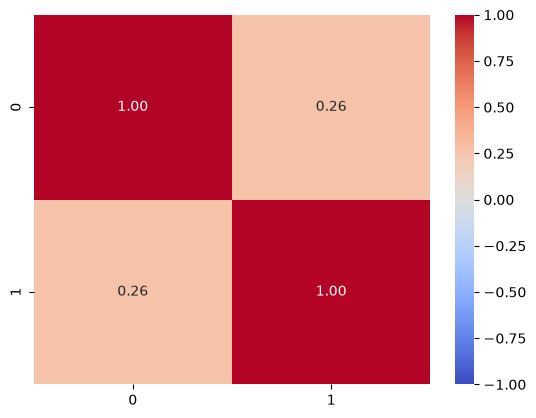

In [575]:
c_rev_avaliac = np.corrcoef(array_revpar, array_avaliac)
sns.heatmap(c_rev_avaliac, 
            annot=True,
            cmap='coolwarm', 
            vmin=-1,
            vmax=1,
            fmt='.2f'
            )

Correlação do semestre de 26:

In [576]:
array_revpar26 = np.array(df_revpar_semestre26['revpar'])
array_avaliac26 = np.array(df_revpar_semestre26['avaliacao_media'])

<Axes: >

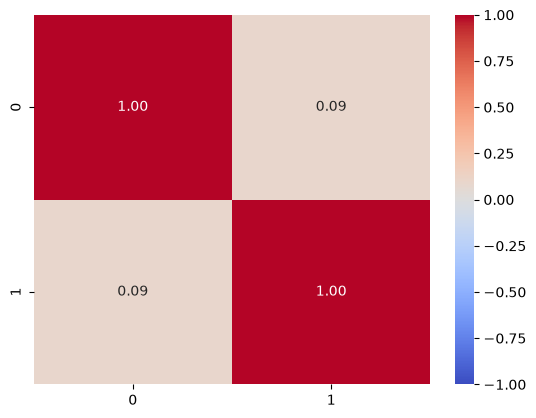

In [577]:
c_rev_avaliac26 = np.corrcoef(array_revpar26, array_avaliac26)
sns.heatmap(c_rev_avaliac26, 
            annot=True,
            cmap='coolwarm', 
            vmin=-1,
            vmax=1,
            fmt='.2f'
            )

Pergunta 5: Uma analise não é possível porque a correlação entre avaliação e revpar é baixa, construir um modelo abriria margens altas de erro

## Pergunta 6:

Geral:

In [578]:
variancia_fat = np.var(array_faturamento)
std_fat = np.std(array_faturamento)
print(f'Variancia: {variancia_fat:.2f} \nSTD: {std_fat:.2f}')
print(f"Faixa típica: {media_fat-std_fat:.2f} até {media_fat+std_fat:.2f}")

Variancia: 14417789744.38 
STD: 120074.10
Faixa típica: 547732.82 até 787881.02


In [579]:
df_unidades

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 Estrelas,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4 Estrelas,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3 Estrelas,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 Estrelas,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 Estrelas,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3 Estrelas,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5 Estrelas,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4 Estrelas,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4 Estrelas,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5 Estrelas,75


Função assim eu não fico repetindo o codigo:

In [580]:
def derivacao_regiao(regiao):
    df_regiao = df_faturamento.loc[df_faturamento['regiao'] == regiao]
    array = np.array(df_regiao['preco_total'])
    media = np.mean(array)
    variancia = np.var(array)
    std = np.std(array)
    menor_val = media-std
    maior_val = media+std
    print(f'Variancia: {variancia:.2f} \nSTD: {std:.2f}')
    print(f"Faixa típica: {menor_val:.2f} até {maior_val:.2f}")
    return {'df': df_regiao, 'media': media, 'variancia': variancia, 'std': std, 'menor': menor_val, 'maior': maior_val}

capital:

In [581]:
capital = derivacao_regiao('Capital')

Variancia: 11111998576.00 
STD: 105413.46
Faixa típica: 527668.54 até 738495.46


In [582]:
capital['df']

,id_unidade,nome_unidade,regiao,preco_total
3,4,NaraHoteis Santa Teresa,Capital,734400.0
1,2,NaraHoteis Barra da Tijuca,Capital,697680.0
0,1,NaraHoteis Ipanema,Capital,688410.0
12,13,NaraHoteis Copacabana Premium,Capital,604880.0
2,3,NaraHoteis Centro,Capital,440040.0


Costa verde:

In [583]:
costver = derivacao_regiao('Costa Verde')

Variancia: 1613332066.67 
STD: 40166.31
Faixa típica: 706823.69 até 787156.31


In [584]:
costver['df']

,id_unidade,nome_unidade,regiao,preco_total
11,12,NaraHoteis Mangaratiba,Costa Verde,777300.0
9,10,NaraHoteis Paraty,Costa Verde,773440.0
10,11,NaraHoteis Angra dos Reis,Costa Verde,690230.0


Baixada:

In [585]:
baixada = derivacao_regiao('Baixada Fluminense')

Variancia: 33067604025.00 
STD: 181845.00
Faixa típica: 371800.00 até 735490.00


In [586]:
baixada['df']

,id_unidade,nome_unidade,regiao,preco_total
5,6,NaraHoteis Nova Iguaçu Park,Baixada Fluminense,735490.0
4,5,NaraHoteis Nova Iguaçu Centro,Baixada Fluminense,371800.0


Serra

In [587]:
serra = derivacao_regiao('Serra')

Variancia: 327388022.22 
STD: 18093.87
Faixa típica: 704512.80 até 740700.53


In [588]:
serra['df']

,id_unidade,nome_unidade,regiao,preco_total
8,9,NaraHoteis Friburgo,Serra,744480.0
7,8,NaraHoteis Teresópolis,Serra,723170.0
6,7,NaraHoteis Petrópolis,Serra,700170.0


## Extra:

In [589]:
r_fat_avaliac = np.corrcoef(array_faturamento, array_avaliac)

<Axes: >

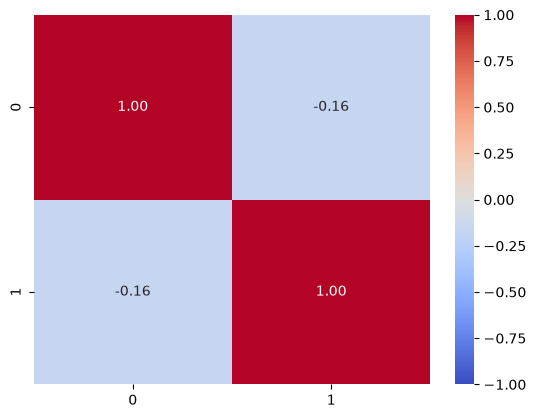

In [590]:
sns.heatmap(r_fat_avaliac, 
            annot=True,
            cmap='coolwarm', 
            vmin=-1,
            vmax=1,
            fmt='.2f'
            )